Data Loaded: 5746 rows, 22 columns
Key Volatility/Flow Columns: ['iv_30d', 'iv_60d', 'iv_90d', 'pc_ratio_vol', 'pc_ratio_oi', 'net_gamma', 'vrp_30d']
Modeling Dataset: 5723 rows after dropping NaN lags.
Elastic Net Features (11): ['rv30_ann', 'iv_30d', 'iv_60d', 'iv_90d', 'term_slope', 'term_curvature', 'skew_30d', 'vrp_30d', 'net_gamma', 'pc_ratio_vol', 'pc_ratio_oi']

Training HAR-RV Benchmark...
HAR-RV Coefficients:
const      -1.203006
log_rv_d    0.688505
log_rv_w   -0.492853
log_rv_m    0.513375
dtype: float64

Training Elastic Net...
Elastic Net Non-Zero Coefficients: 9

PERFORMANCE COMPARISON (Out-of-Sample)
               RMSE      MAE    QLIKE  MSE_Log  HitRate  RMSE_Imp%
Model                                                             
HAR-RV      0.08713  0.05049 -1.21178  1.42751  0.49271    0.00000
ElasticNet  0.08032  0.05018 -1.23258  1.42311  0.49155    7.81848

Elastic Net RMSE Improvement: 7.82%

------------------------------------------------------------
STATISTIC

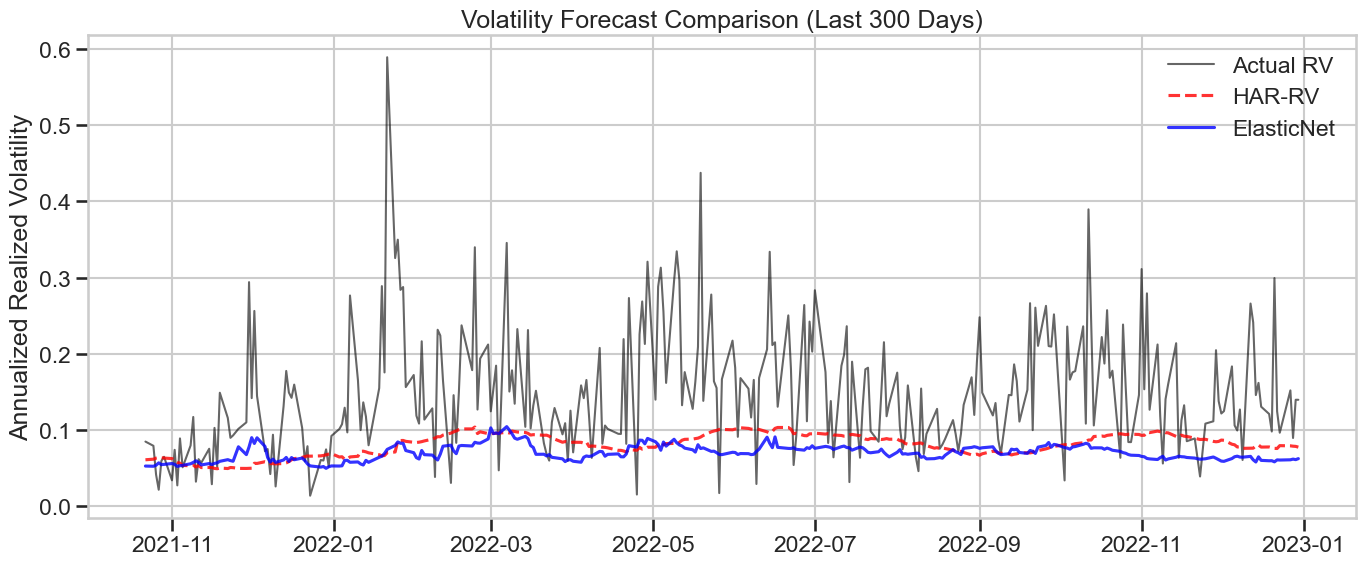

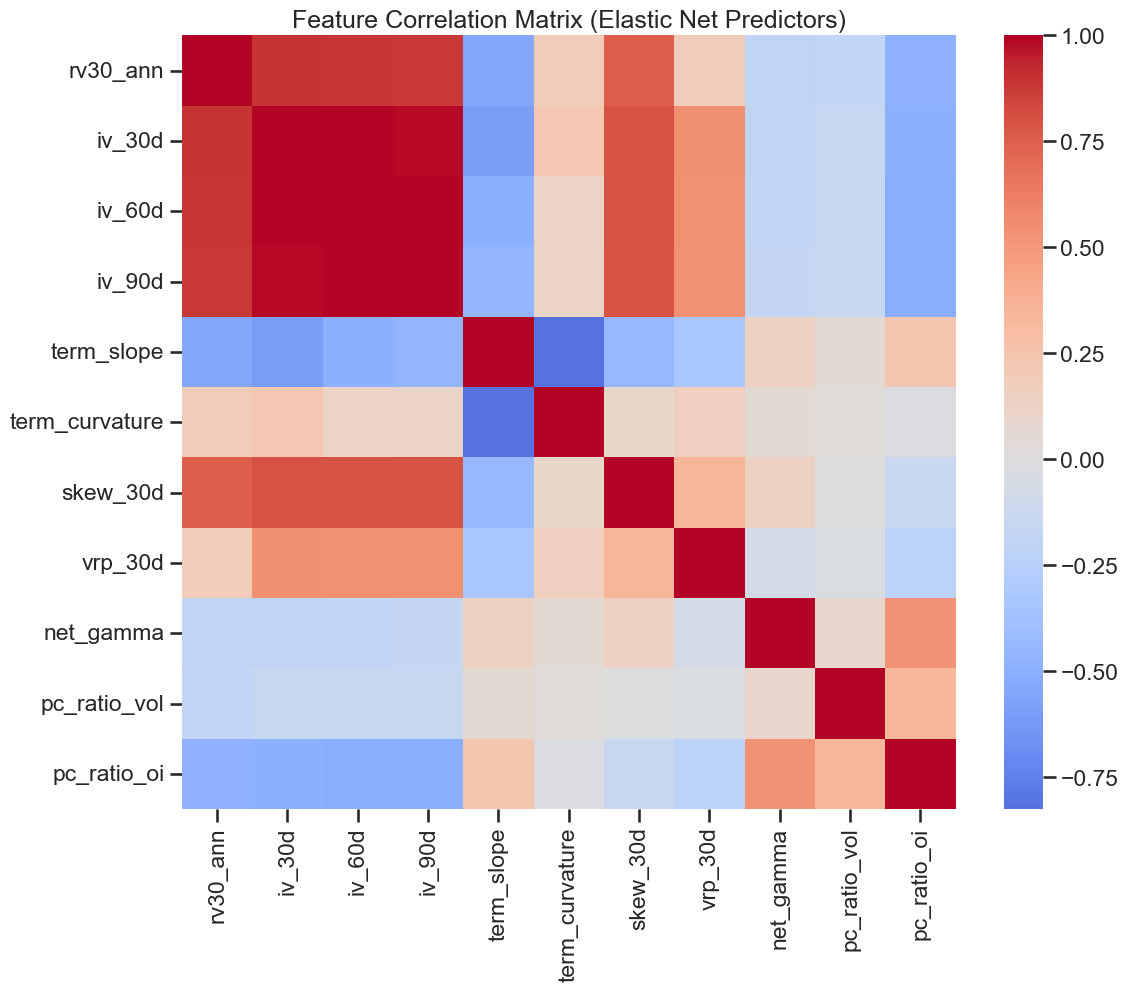

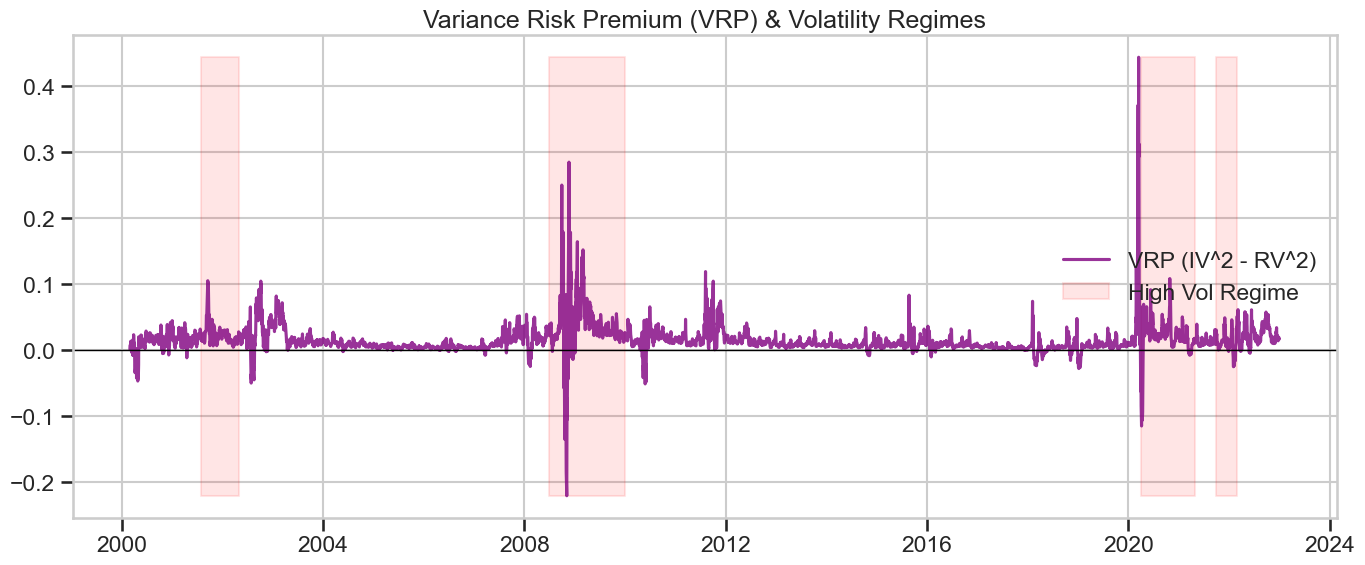

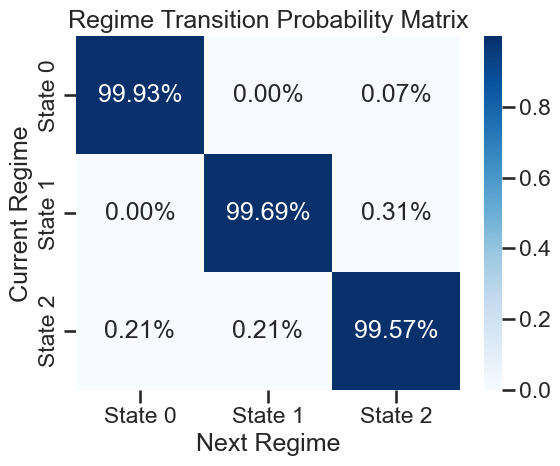


Expected Regime Durations (Days):
State 0: 1495.7 days
State 1: 318.0 days
State 2: 235.0 days


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

# ==============================================================================
# 0. CONFIGURATION & UTILITY FUNCTIONS
# ==============================================================================

# --- Plotting Style ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_context("talk")

def qlike_loss(y_true, y_pred):
    """
    Quasi-Likelihood Loss function (robust for volatility).
    L(y, y_hat) = log(y_hat) + y/y_hat
    """
    y_pred = np.maximum(np.asarray(y_pred), 1e-8)
    y_true = np.maximum(np.asarray(y_true), 1e-8)
    return np.mean(np.log(y_pred) + (y_true / y_pred))

def mse_log_rv(y_true, y_pred):
    """
    Mean Squared Error of log-transformed Realized Volatility.
    This metric handles the heteroskedasticity of vol data well.
    """
    y_true = np.maximum(np.asarray(y_true), 1e-8)
    y_pred = np.maximum(np.asarray(y_pred), 1e-8)
    return np.mean((np.log(y_true) - np.log(y_pred))**2)

def directional_hit_rate(y_true, y_pred):
    """
    Hit Rate for predicting the DIRECTION of volatility change.
    Returns the percentage of times sign(d_true) == sign(d_pred).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) < 2:
        return np.nan
    diff_true = np.diff(y_true)
    diff_pred = np.diff(y_pred)
    
    # Filter out cases where actual change is exactly zero (rare in float data)
    mask = diff_true != 0
    if mask.sum() == 0:
        return np.nan
        
    return np.mean(np.sign(diff_true[mask]) == np.sign(diff_pred[mask]))

def dm_test(actual, pred1, pred2, h=1, loss_type='MSE'):
    """
    Diebold-Mariano test for predictive accuracy.
    H0: Both models have equal accuracy.
    Returns: DM statistic, p-value
    """
    e1 = actual - pred1
    e2 = actual - pred2
    
    if loss_type == 'MSE':
        d = e1**2 - e2**2
    elif loss_type == 'MAE':
        d = np.abs(e1) - np.abs(e2)
    elif loss_type == 'QLIKE':
        # QLIKE diff
        loss1 = np.log(np.maximum(pred1, 1e-8)) + actual/np.maximum(pred1, 1e-8)
        loss2 = np.log(np.maximum(pred2, 1e-8)) + actual/np.maximum(pred2, 1e-8)
        d = loss1 - loss2
        
    T = float(len(d))
    mean_d = np.mean(d)
    
    # Newey-West autocovariance correction
    gamma0 = np.var(d)
    if h > 1:
        gamma_lag = 0
        for i in range(1, h):
            gamma_lag += np.cov(d[i:], d[:-i])[0,1]
        var_d = gamma0 + 2*gamma_lag
    else:
        var_d = gamma0
        
    dm_stat = mean_d / np.sqrt(var_d / T)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    
    return dm_stat, p_value

def ensure_aligned(a, b):
    """
    Aligns two pandas Series/DataFrames by their index intersection.
    Returns numpy arrays of the aligned data and the common index.
    """
    if isinstance(a, (pd.Series, pd.DataFrame)) and isinstance(b, (pd.Series, pd.DataFrame)):
        common_idx = a.index.intersection(b.index)
        return np.asarray(a.loc[common_idx]), np.asarray(b.loc[common_idx]), common_idx
    else:
        # Fallback for array inputs (assumes already aligned)
        a = np.asarray(a)
        b = np.asarray(b)
        n = min(len(a), len(b))
        return a[:n], b[:n], None

# ==============================================================================
# 1. LOAD DATA & MERGE REGIMES
# ==============================================================================

# Define paths (adjust relative path if notebook location differs)
DATA_DIR = os.path.join("..", "data", "master")
FEAT_FILE = os.path.join(DATA_DIR, "iv_features_spx_2000_2022.csv")
REGIME_FILE = os.path.join(DATA_DIR, "hmm_macro_regimes_monthly.csv")

if not os.path.exists(FEAT_FILE):
    raise FileNotFoundError(f"Feature file missing: {FEAT_FILE}. Please run features_vol_surface_v2.py.")

# Load main features
df = pd.read_csv(FEAT_FILE, parse_dates=["date"]).set_index("date").sort_index()

# Check for required columns from feature engineering step
required_cols = ["rv30_ann", "target_rv_next_day"]
for c in required_cols:
    if c not in df.columns:
        raise KeyError(f"Critical column '{c}' missing. Check feature generation script.")

# Create Log-RV targets for modeling (variance stabilization)
df["log_rv"] = np.log(np.maximum(df["rv30_ann"], 1e-8))
df["log_rv_next"] = np.log(np.maximum(df["target_rv_next_day"], 1e-8))

# Merge HMM Regimes
if os.path.exists(REGIME_FILE):
    regimes = pd.read_csv(REGIME_FILE, parse_dates=["date"]).set_index("date").sort_index()
    
    # Standardize column names
    rename_map = {}
    if "hmm_state" in regimes.columns: rename_map["hmm_state"] = "Regime"
    if "regime" in regimes.columns: rename_map["regime"] = "Regime"
    regimes = regimes.rename(columns=rename_map)
    
    # Keep probabilities if they exist
    prob_cols = [c for c in regimes.columns if "prob" in c.lower()]
    cols_to_keep = ["Regime"] + prob_cols if "Regime" in regimes.columns else prob_cols
    regimes = regimes[cols_to_keep]
    
    # Join (Left join to keep daily price dates)
    df = df.join(regimes, how="left")
    
    # Forward fill regimes (monthly data -> daily)
    if "Regime" in df.columns:
        df["Regime"] = df["Regime"].ffill().bfill().astype(int)
else:
    print("Warning: Regime file not found. Setting dummy regime.")
    df["Regime"] = 0

print(f"Data Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("Key Volatility/Flow Columns:", [c for c in df.columns if any(x in c for x in ['iv_', 'vrp', 'vix', 'gamma', 'pc_'])][:15])

# ==============================================================================
# 2. FEATURE ENGINEERING (HAR & ELASTIC NET SETS)
# ==============================================================================

# --- HAR-RV Feature Construction ---
# HAR predictors: RV_daily (lag 1), RV_weekly (avg lag 1-5), RV_monthly (avg lag 1-22)
# We calculate these on the log scale for the linear model
df["log_rv_d"] = df["log_rv"].shift(1)
df["log_rv_w"] = df["log_rv"].rolling(5).mean().shift(1)
df["log_rv_m"] = df["log_rv"].rolling(22).mean().shift(1)
har_features = ["log_rv_d", "log_rv_w", "log_rv_m"]

# --- Elastic Net Feature Set ---
# This includes the IV Surface, VRP, Option Flows, and VIX metrics
enet_candidates = [
    "rv30_ann",         # Recent realized vol level
    "iv_30d", "iv_60d", "iv_90d",  # ATM Term Structure
    "term_slope", "term_curvature",
    "skew_30d",         # Smile
    "vix_level", "vix_gap", 
    "vrp_30d",          # Variance Risk Premium
    "net_gamma",        # Flow / Dealer positioning
    "pc_ratio_vol", "pc_ratio_oi"
]
if "vvix_level" in df.columns: enet_candidates.append("vvix_level")

# Filter for existing columns
enet_features = [c for c in enet_candidates if c in df.columns]

# Create modeling dataset (drop NaNs created by lags/rolling windows)
# We need valid data for BOTH sets of features
all_required_cols = har_features + enet_features + ["target_rv_next_day", "log_rv_next"]
df_model = df.dropna(subset=all_required_cols).copy()

print(f"Modeling Dataset: {len(df_model)} rows after dropping NaN lags.")
print(f"Elastic Net Features ({len(enet_features)}): {enet_features}")

# ==============================================================================
# 3. TRAIN-TEST SPLIT
# ==============================================================================

split_point = int(len(df_model) * 0.7)
train_df = df_model.iloc[:split_point]
test_df = df_model.iloc[split_point:]

# Targets (Level for final metric, Log for model training)
y_train_log = train_df["log_rv_next"]
y_test_log = test_df["log_rv_next"]
y_test_level = test_df["target_rv_next_day"] # For final RMSE evaluation

# ==============================================================================
# 4. BENCHMARK MODEL: HAR-RV
# ==============================================================================

print("\nTraining HAR-RV Benchmark...")
X_train_har = sm.add_constant(train_df[har_features])
X_test_har = sm.add_constant(test_df[har_features])

har_model = sm.OLS(y_train_log, X_train_har).fit()
# Predict log vol, then exponentiate to get level
pred_log_har = har_model.predict(X_test_har)
pred_har_level = np.exp(pred_log_har)

print("HAR-RV Coefficients:")
print(har_model.params)

# ==============================================================================
# 5. CHALLENGER MODEL: ELASTIC NET (Regime Conditional)
# ==============================================================================

print("\nTraining Elastic Net...")
# Scale features (critical for regularization)
scaler = StandardScaler()
X_train_en = scaler.fit_transform(train_df[enet_features])
X_test_en = scaler.transform(test_df[enet_features])

# Train (Mixing L1/L2 penalty)
# Note: Using log-RV target for stability/normality
en_model = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000, random_state=42)
en_model.fit(X_train_en, y_train_log)

# Predict
pred_log_en = en_model.predict(X_test_en)
pred_en_level = np.exp(pred_log_en)

print("Elastic Net Non-Zero Coefficients:", np.sum(en_model.coef_ != 0))

# ==============================================================================
# 6. EVALUATION & METRICS COMPARISON
# ==============================================================================

# Align arrays (just to be safe, though indices should match)
# We align everything to the Test Index
aligned_y_true, aligned_har, idx = ensure_aligned(y_test_level, pd.Series(pred_har_level, index=test_df.index))
_, aligned_en, _ = ensure_aligned(y_test_level, pd.Series(pred_en_level, index=test_df.index))

# Metrics Calculation Helper
def calc_metrics(true, pred, model_name):
    return {
        "Model": model_name,
        "RMSE": np.sqrt(mean_squared_error(true, pred)),
        "MAE": mean_absolute_error(true, pred),
        "QLIKE": qlike_loss(true, pred),
        "MSE_Log": mse_log_rv(true, pred),
        "HitRate": directional_hit_rate(true, pred)
    }

res_har = calc_metrics(aligned_y_true, aligned_har, "HAR-RV")
res_en = calc_metrics(aligned_y_true, aligned_en, "ElasticNet")

# Create Comparison Table
comp_table = pd.DataFrame([res_har, res_en]).set_index("Model")
# Calculate % Improvement (Negative change in Error is good, Positive change in HitRate is good)
har_rmse = comp_table.loc["HAR-RV", "RMSE"]
en_rmse = comp_table.loc["ElasticNet", "RMSE"]
imp_rmse = (har_rmse - en_rmse) / har_rmse * 100

comp_table["RMSE_Imp%"] = [0, imp_rmse]

print("\n" + "="*60)
print("PERFORMANCE COMPARISON (Out-of-Sample)")
print("="*60)
print(comp_table.round(5))
print(f"\nElastic Net RMSE Improvement: {imp_rmse:.2f}%")

# ==============================================================================
# 7. STATISTICAL SIGNIFICANCE (Diebold-Mariano)
# ==============================================================================

dm_stat, dm_p = dm_test(aligned_y_true, aligned_har, aligned_en, h=1, loss_type='MSE')

print("\n" + "-"*60)
print("STATISTICAL SIGNIFICANCE (Diebold-Mariano Test)")
print("-" * 60)
print(f"DM Statistic: {dm_stat:.4f}")
print(f"P-Value:      {dm_p:.4f}")
if dm_p < 0.05:
    print("Result:       Statistically Significant Difference (p < 0.05)")
    if dm_stat > 0:
        print("Winner:       Elastic Net (Errors significantly smaller)")
    else:
        print("Winner:       HAR-RV")
else:
    print("Result:       No statistically significant difference")
print("="*60)

# ==============================================================================
# 8. VISUALIZATIONS
# ==============================================================================

# A. Time Series Forecast
plot_len = 300 # Last 300 days for clarity
dates_plot = idx[-plot_len:]

plt.figure(figsize=(14, 6))
plt.plot(dates_plot, aligned_y_true[-plot_len:], color='black', label='Actual RV', alpha=0.6, linewidth=1.5)
plt.plot(dates_plot, aligned_har[-plot_len:], color='red', label='HAR-RV', linestyle='--', alpha=0.8)
plt.plot(dates_plot, aligned_en[-plot_len:], color='blue', label='ElasticNet', alpha=0.8)
plt.title(f"Volatility Forecast Comparison (Last {plot_len} Days)")
plt.ylabel("Annualized Realized Volatility")
plt.legend()
plt.tight_layout()
plt.show()

# B. Feature Correlations
plt.figure(figsize=(12, 10))
sns.heatmap(train_df[enet_features].corr(), cmap='coolwarm', center=0, square=True, annot=False)
plt.title("Feature Correlation Matrix (Elastic Net Predictors)")
plt.tight_layout()
plt.show()

# C. VRP Analysis with Regimes
if "vrp_30d" in df.columns:
    plt.figure(figsize=(14, 6))
    plt.plot(df.index, df["vrp_30d"], label="VRP (IV^2 - RV^2)", color='purple', alpha=0.8)
    plt.axhline(0, color='black', linewidth=1)
    
    # Shade regimes if available
    if "Regime" in df.columns:
        regime_data = df["Regime"].astype(int)
        unique_regimes = sorted(regime_data.unique())
        # Use different background colors for regimes
        colors = ['green', 'yellow', 'red']
        for r in unique_regimes:
            mask = regime_data == r
            if mask.sum() > 0:
                # Find contiguous periods is complex for plotting, simplified scatter approach often better
                # or just shade the 'High Vol' regime (usually highest index)
                if r == max(unique_regimes):
                    plt.fill_between(df.index, df["vrp_30d"].min(), df["vrp_30d"].max(), 
                                     where=mask, color='red', alpha=0.1, label='High Vol Regime')

    plt.title("Variance Risk Premium (VRP) & Volatility Regimes")
    plt.legend()
    plt.tight_layout()
    plt.show()

# D. Regime Transition Matrix
if "Regime" in df.columns:
    regime_series = df["Regime"].dropna().astype(int)
    states = sorted(regime_series.unique())
    n_states = len(states)
    
    trans_counts = np.zeros((n_states, n_states))
    
    # Iterate through time series to count transitions
    # Note: regime_series.values creates numpy array for speed
    r_vals = regime_series.values
    for i in range(len(r_vals)-1):
        curr = r_vals[i]
        next_ = r_vals[i+1]
        # Map state value to index if not 0,1,2...
        # Assuming 0,1,2 for simplicity based on HMM script
        if curr < n_states and next_ < n_states:
            trans_counts[curr, next_] += 1
            
    # Normalize rows to sum to 1
    row_sums = trans_counts.sum(axis=1, keepdims=True)
    trans_probs = np.divide(trans_counts, row_sums, out=np.zeros_like(trans_counts), where=row_sums!=0)
    
    # Plot Heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(trans_probs, annot=True, fmt=".2%", cmap="Blues", 
                xticklabels=[f"State {s}" for s in states],
                yticklabels=[f"State {s}" for s in states])
    plt.title("Regime Transition Probability Matrix")
    plt.ylabel("Current Regime")
    plt.xlabel("Next Regime")
    plt.tight_layout()
    plt.show()
    
    # Calc durations
    diags = np.diag(trans_probs)
    print("\nExpected Regime Durations (Days):")
    for i, p in enumerate(diags):
        dur = 1/(1-p) if p < 1 else np.inf
        print(f"State {states[i]}: {dur:.1f} days")

Initializing Dollarized Trading Strategy...

💰 STRATEGY PERFORMANCE REPORT (Notional: $1000 per 1% Vol Edge)
Total Profit/Loss (after costs): $9,265,778.65
Sharpe Ratio (after costs):      14.32
Sortino Ratio (after costs):     15.21
Max Dollar Drawdown:             $-70,828.63
Win Rate (after costs):          88.5%
--------------------------------------------------------------------------------
PERFORMANCE BY REGIME ($) (after costs):
                        Days  Total_Profit_$  Avg_Daily_Profit_$  RMSE
Regime_Label                                                          
High Vol / Crisis        319    2,269,644.96            7,114.87  0.09
Low Vol Environment     1022    3,994,080.84            3,908.10  0.07
Normal Vol Environment   376    3,002,052.85            7,984.18  0.09


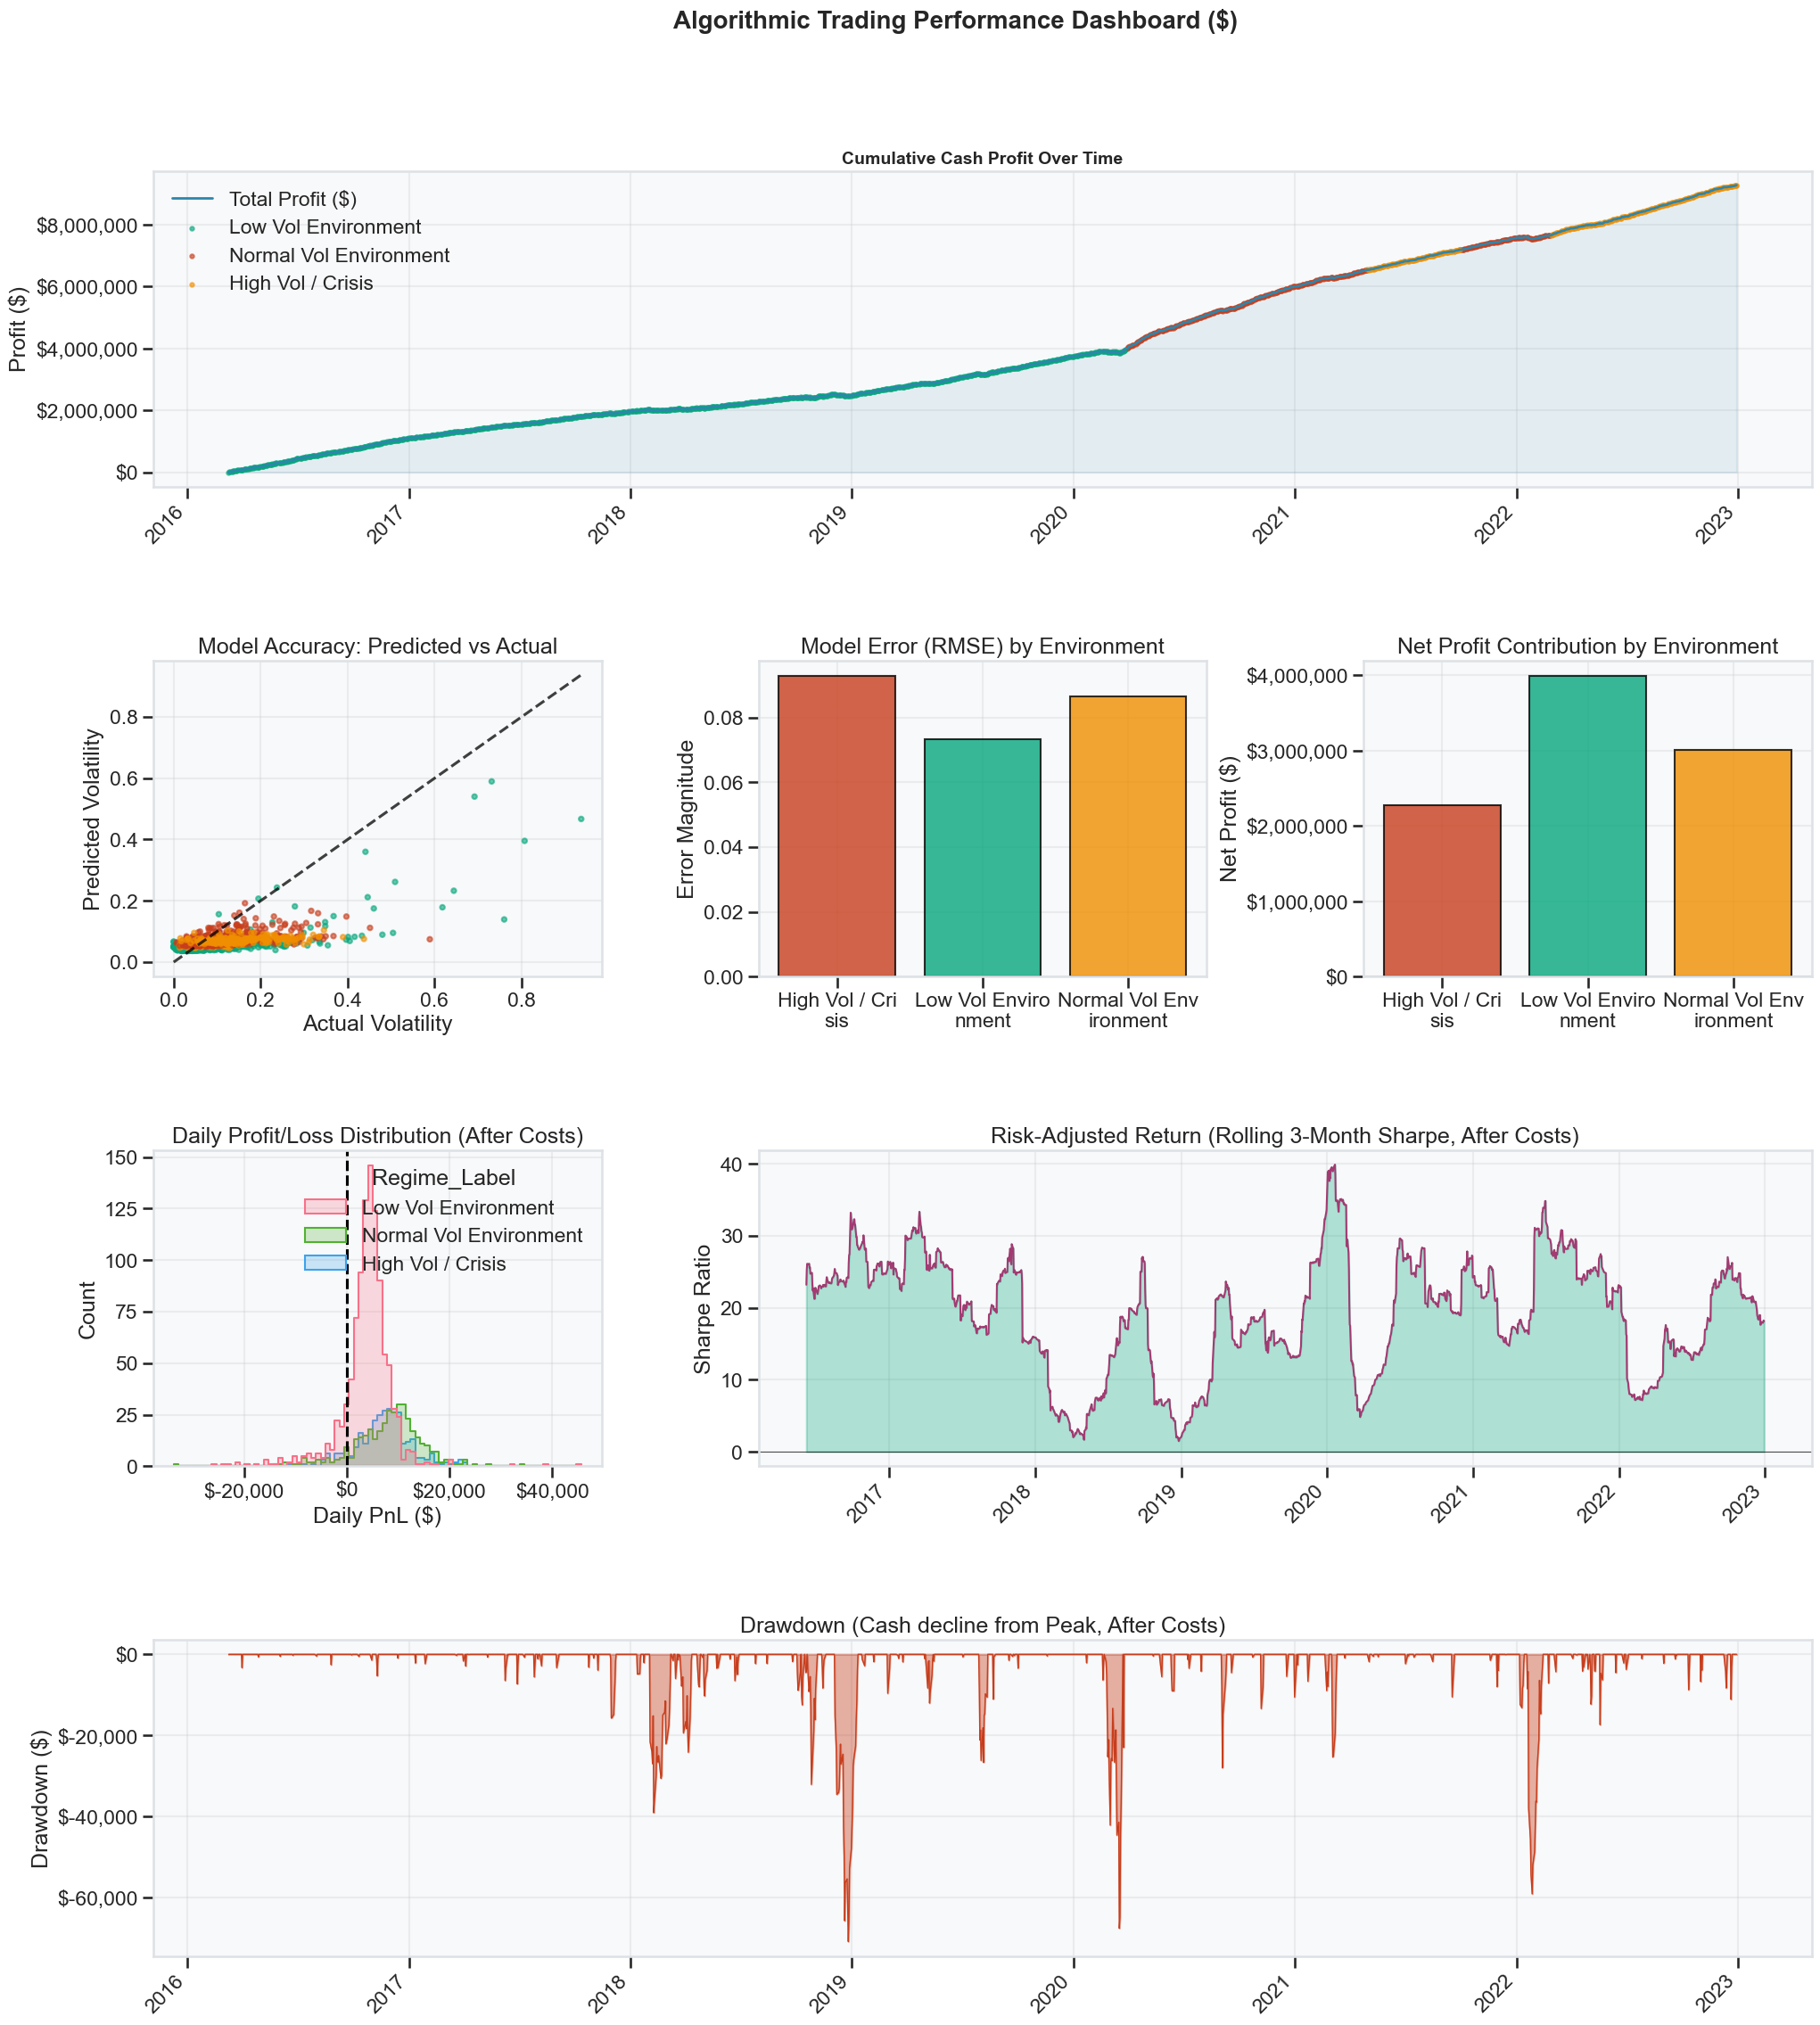

In [10]:
# ==============================================================================
# 9. TRADING STRATEGY & ADVANCED VISUALIZATION (DOLLARIZED)
# ==============================================================================

# --- A. Visualization Configuration ---
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.edgecolor': '#DEE2E6',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
})

COLORS = {
    'primary': '#2E86AB',      # Deep Blue
    'secondary': '#A23B72',    # Purple
    'accent': '#F18F01',       # Orange
    'success': '#06A77D',      # Green
    'danger': '#C73E1D',       # Red
    'neutral': '#6C757D',      # Gray
    'regime_0': '#06A77D',     # Low Vol (Green)
    'regime_1': '#F18F01',     # Med Vol (Orange)
    'regime_2': '#C73E1D'      # High Vol (Red)
}

# --- B. Financial Metrics Helpers ---
def calculate_sharpe(pnl_series):
    if pnl_series.std() == 0: return 0
    return (pnl_series.mean() / pnl_series.std()) * np.sqrt(252)

def calculate_sortino(pnl_series):
    downside = pnl_series[pnl_series < 0]
    if len(downside) == 0 or downside.std() == 0: return 0
    return (pnl_series.mean() / downside.std()) * np.sqrt(252)

def calculate_max_drawdown(equity_curve):
    # Calculate Peak-to-Trough decline in Dollars
    running_max = equity_curve.cummax()
    drawdown = (equity_curve - running_max)
    return drawdown.min()

# --- C. Implement Dollarized Strategy ---
print("Initializing Dollarized Trading Strategy...")

# 1. Configuration: "Vega Notional"
# This represents how much money we make per 1% difference in volatility.
# Value of $1,000 implies we bet $1k for every 1% edge we find.
VEGA_NOTIONAL = 1000 

strat = test_df[['iv_30d', 'Regime']].copy()
strat['Forecast_Vol'] = pred_en_level  
strat['Actual_RV'] = y_test_level

# 2. Generate Signals
# Logic: If Forecast > Implied, Buy Straddle (Long Vol). If Forecast < Implied, Sell Straddle.
strat['Signal_Premium'] = strat['Forecast_Vol'] - strat['iv_30d']
strat['Position'] = np.sign(strat['Signal_Premium'])

# 3. Calculate Dollar PnL (before costs)
# Math: (Actual - Implied) * 100 (to convert decimal to %) * Vega Notional
# Example: 21% RV - 20% IV = 1% edge. 1 * $1,000 = +$1,000 Profit.
strat['PnL'] = strat['Position'] * (strat['Actual_RV'] - strat['iv_30d']) * 100 * VEGA_NOTIONAL

# --- D. BOTH-SIDE TRANSACTION COST: 0.5% PER SIDE (1% ROUND-TRIP) ---
TXN_COST_RATE_PER_SIDE = 0.005  # 0.5% per side

# Number of "sides" traded each day = |Position_today - Position_yesterday|
# 0 -> +1 (or -1): 1 side (enter)
# +1 -> 0 (or -1 -> 0): 1 side (exit)
# +1 -> -1 (or -1 -> +1): 2 sides (exit + enter)
prev_pos = strat['Position'].shift(1).fillna(0)
strat['Trade_Sides'] = (strat['Position'] - prev_pos).abs()

# Dollar transaction cost
strat['Txn_Cost'] = strat['Trade_Sides'] * TXN_COST_RATE_PER_SIDE * VEGA_NOTIONAL

# Net PnL after transaction costs
strat['PnL_after_cost'] = strat['PnL'] - strat['Txn_Cost']

# 4. Equity Curve ($) using cost-adjusted PnL
strat['Equity'] = strat['PnL_after_cost'].cumsum()

# --- E. Regime Mapping ---
regime_means = strat.groupby('Regime')['Actual_RV'].mean()
sorted_regimes = regime_means.sort_values().index
regime_map = {
    sorted_regimes[0]: 'Low Vol Environment',
    sorted_regimes[1]: 'Normal Vol Environment',
    sorted_regimes[2]: 'High Vol / Crisis'
}
strat['Regime_Label'] = strat['Regime'].map(regime_map)
strat['Regime_Color'] = strat['Regime'].map({
    sorted_regimes[0]: COLORS['regime_0'],
    sorted_regimes[1]: COLORS['regime_1'],
    sorted_regimes[2]: COLORS['regime_2']
})

# Calculate Dollar Stats by Regime (after costs)
regime_stats = strat.groupby('Regime_Label').agg({
    'PnL_after_cost': ['count', 'sum', 'mean'],
    'Forecast_Vol': 'mean'  # Placeholder for alignment
})
regime_stats.columns = ['Days', 'Total_Profit_$', 'Avg_Daily_Profit_$', 'Avg_Forecast']

# Add RMSE manually to this summary
rmse_per_regime = {}
for lbl in regime_stats.index:
    subset = strat[strat['Regime_Label'] == lbl]
    rmse_per_regime[lbl] = np.sqrt(mean_squared_error(subset['Actual_RV'], subset['Forecast_Vol']))
regime_stats['RMSE'] = pd.Series(rmse_per_regime)

# --- F. Executive Summary ($) ---
print("\n" + "="*80)
print(f"💰 STRATEGY PERFORMANCE REPORT (Notional: ${VEGA_NOTIONAL} per 1% Vol Edge)")
print("="*80)
total_ret = strat['Equity'].iloc[-1]
print(f"Total Profit/Loss (after costs): ${total_ret:,.2f}")
print(f"Sharpe Ratio (after costs):      {calculate_sharpe(strat['PnL_after_cost']):.2f}")
print(f"Sortino Ratio (after costs):     {calculate_sortino(strat['PnL_after_cost']):.2f}")
print(f"Max Dollar Drawdown:             ${calculate_max_drawdown(strat['Equity']):,.2f}")
print(f"Win Rate (after costs):          {(strat['PnL_after_cost'] > 0).mean() * 100:.1f}%")
print("-" * 80)
print("PERFORMANCE BY REGIME ($) (after costs):")
# Format the table nicely
display_stats = regime_stats[['Days', 'Total_Profit_$', 'Avg_Daily_Profit_$', 'RMSE']].copy()
pd.options.display.float_format = '{:,.2f}'.format
print(display_stats)
print("="*80)

# --- G. Dollarized Dashboard Plot ---

## --- G. Dollarized Dashboard Plot ---

# Larger figure & *more* spacing for clearer labels
fig = plt.figure(figsize=(24, 26))
gs = fig.add_gridspec(4, 3, hspace=0.55, wspace=0.35)
fig.suptitle('Algorithmic Trading Performance Dashboard ($)', fontsize=20,
             fontweight='bold', y=0.95)

# 1. Cumulative Profit Curve ($)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(strat.index, strat['Equity'], color=COLORS['primary'], linewidth=2, label='Total Profit ($)')
ax1.fill_between(strat.index, 0, strat['Equity'], color=COLORS['primary'], alpha=0.1)

for r_code in sorted_regimes:
    mask = strat['Regime'] == r_code
    if mask.sum() > 0:
        r_label = regime_map[r_code]
        color = COLORS[f'regime_{r_code}']
        ax1.scatter(strat[mask].index, strat[mask]['Equity'], color=color, s=10, label=r_label, alpha=0.6)

ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax1.set_title('Cumulative Cash Profit Over Time', fontsize=14, fontweight='bold')
ax1.set_ylabel("Profit ($)")
ax1.legend(loc='upper left')

# 2. Forecast Accuracy (Scatter)
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(strat['Actual_RV'], strat['Forecast_Vol'], 
            c=strat['Regime'].map({0: COLORS['regime_0'], 1: COLORS['regime_1'], 2: COLORS['regime_2']}),
            alpha=0.6, s=15)
lims = [0, max(strat['Actual_RV'].max(), strat['Forecast_Vol'].max())]
ax2.plot(lims, lims, 'k--', alpha=0.75)
ax2.set_xlabel('Actual Volatility')
ax2.set_ylabel('Predicted Volatility')
ax2.set_title('Model Accuracy: Predicted vs Actual')

# 3. Model Error by Environment
ax3 = fig.add_subplot(gs[1, 1])
bar_colors = [strat[strat['Regime_Label'] == idx]['Regime_Color'].iloc[0] for idx in regime_stats.index]
ax3.bar(regime_stats.index, regime_stats['RMSE'], color=bar_colors, alpha=0.8, edgecolor='black')
ax3.set_title('Model Error (RMSE) by Environment')
ax3.set_ylabel('Error Magnitude')
# NOTE: leave xticks horizontal here (no rotation) to save vertical space

# 4. Total Profit by Environment (after costs)
ax4 = fig.add_subplot(gs[1, 2])
ax4.bar(regime_stats.index, regime_stats['Total_Profit_$'], color=bar_colors, alpha=0.8, edgecolor='black')
ax4.axhline(0, color='black', linewidth=1)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax4.set_title('Net Profit Contribution by Environment')
ax4.set_ylabel('Net Profit ($)')
# xticks horizontal here as well

def wrap_labels(ax, width=12):
    new_labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        wrapped = '\n'.join([text[i:i+width] for i in range(0, len(text), width)])
        new_labels.append(wrapped)
    ax.set_xticklabels(new_labels)

wrap_labels(ax3, width=14)
wrap_labels(ax4, width=14)

# 5. Daily Profit Distribution (after costs)
ax5 = fig.add_subplot(gs[2, 0])
sns.histplot(data=strat, x='PnL_after_cost', hue='Regime_Label', element="step", ax=ax5, palette='husl')
ax5.axvline(0, color='black', linestyle='--')
ax5.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax5.set_title('Daily Profit/Loss Distribution (After Costs)')
ax5.set_xlabel('Daily PnL ($)')

# 6. Rolling Sharpe Ratio (after costs)
ax6 = fig.add_subplot(gs[2, 1:]) 
rolling_sharpe = strat['PnL_after_cost'].rolling(63).apply(calculate_sharpe)
ax6.plot(rolling_sharpe.index, rolling_sharpe, color=COLORS['secondary'], linewidth=1.5)
ax6.axhline(0, color='black', linewidth=0.5)
ax6.fill_between(rolling_sharpe.index, 0, rolling_sharpe, where=rolling_sharpe > 0,
                 color=COLORS['success'], alpha=0.3)
ax6.fill_between(rolling_sharpe.index, 0, rolling_sharpe, where=rolling_sharpe < 0,
                 color=COLORS['danger'], alpha=0.3)
ax6.set_title('Risk-Adjusted Return (Rolling 3-Month Sharpe, After Costs)')
ax6.set_ylabel("Sharpe Ratio")

# 7. Drawdown ($) based on cost-adjusted equity
ax7 = fig.add_subplot(gs[3, :])
dd = (strat['Equity'] - strat['Equity'].cummax())
ax7.fill_between(dd.index, 0, dd, color=COLORS['danger'], alpha=0.4)
ax7.plot(dd.index, dd, color=COLORS['danger'], linewidth=1)
ax7.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax7.set_title('Drawdown (Cash decline from Peak, After Costs)')
ax7.set_ylabel("Drawdown ($)")

# Rotate x-ticks ONLY on the time-series plots (date index)
for ax in [ax1, ax6, ax7]:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



Initializing Calibrated Smart Engine...
 - Threshold: 0.1% Vol Diff (Aligned to Model distribution)
 - Stops:     Stop -20%, Limit 40%
1. Loading Market Data...
2. Indexing Prices...
3. Running Trading Simulation...

SMART PORTFOLIO PERFORMANCE (Adjusted Thresholds)
Total Profit:       $32,180.00
Trades Closed:      39
Win Rate:           82.1%
Max Drawdown:       $-520.00
Avg Win / Avg Loss: $1053 / $-216


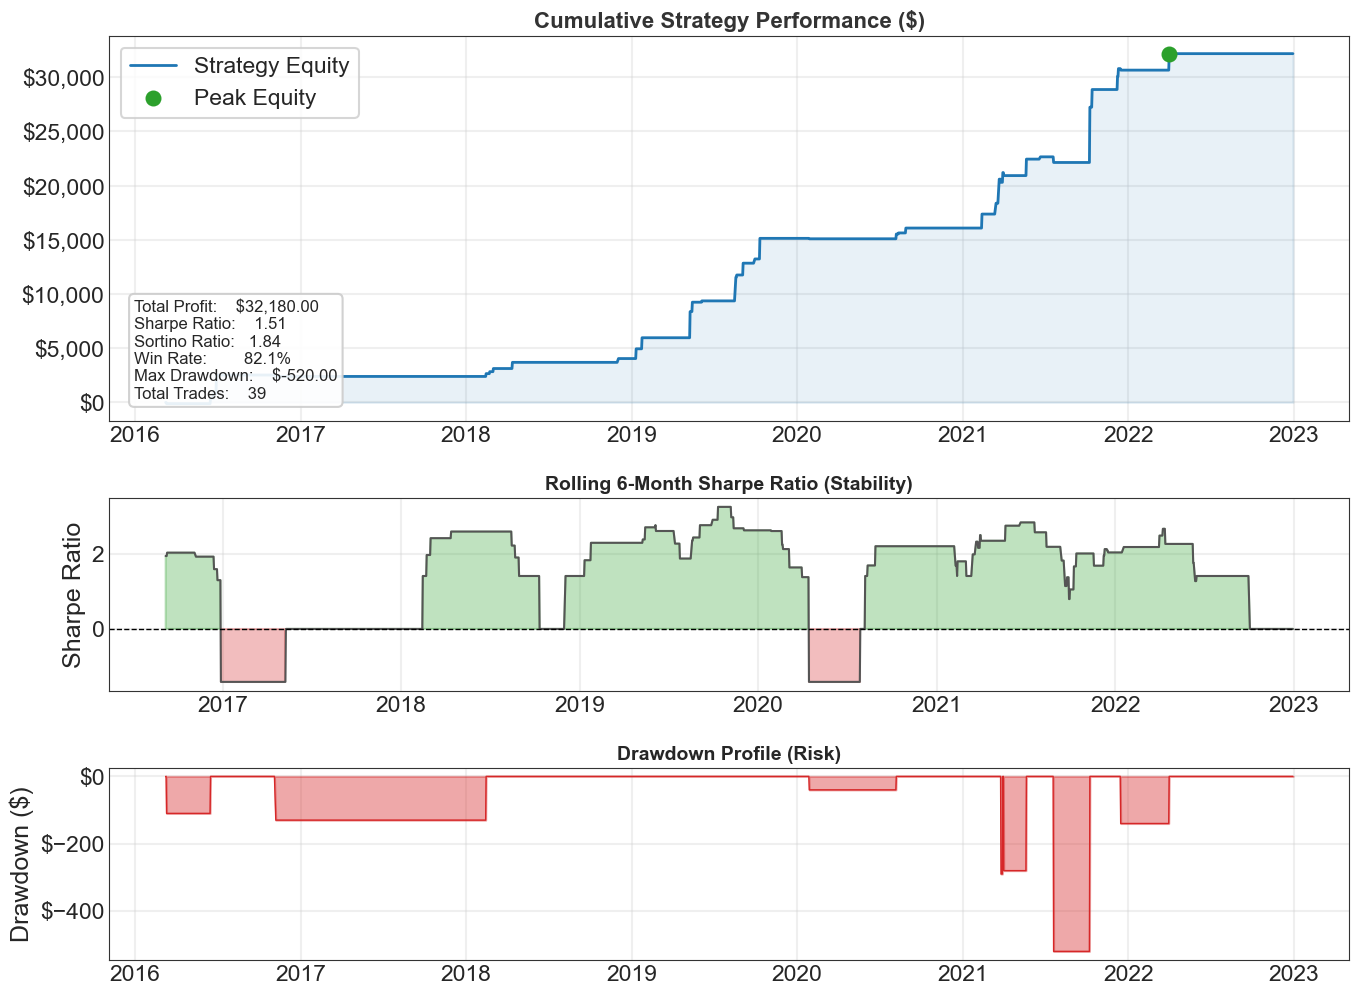

In [14]:
# ==============================================================================
# 13. SMART ENGINE V2 (CALIBRATED THRESHOLDS)
# ==============================================================================

import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
import warnings

warnings.filterwarnings('ignore')

# 1. SETUP
# ========
BASE_PATH = "/Users/areya/Desktop/Project/advanced-vol-forecasting/data/raw"
RAW_OPT_PATH = f"{BASE_PATH}/COMBINED_opprcd_2000_2022.parquet"
RAW_SEC_PATH = f"{BASE_PATH}/COMBINED_secprd_2000_2022.parquet"

# --- CALIBRATED PARAMETERS ---
# We lowered this from 1.5 to 0.10 based on the diagnostic report.
MIN_EDGE_VOL = 0.10      # Trade if Model differs from Market by > 0.10%
STOP_LOSS_PCT = -0.20    # Safety net: Close if we lose 20% on a position
TAKE_PROFIT_PCT = 0.40   # Let winners run a bit more (Short vol pays slowly)
MULTIPLIER = 100         

# Date Range (Test Set)
start_date_ts = test_df.index.min()
end_date_ts = test_df.index.max() + pd.Timedelta(days=5)

print(f"Initializing Calibrated Smart Engine...")
print(f" - Threshold: {MIN_EDGE_VOL}% Vol Diff (Aligned to Model distribution)")
print(f" - Stops:     Stop {STOP_LOSS_PCT:.0%}, Limit {TAKE_PROFIT_PCT:.0%}")

# 2. LOAD DATA
# ============
def get_safe_filters(filepath, start_ts, end_ts):
    try:
        pf = pq.ParquetFile(filepath)
        sample = next(pf.iter_batches(batch_size=1)).to_pandas()['date'].iloc[0]
        if isinstance(sample, str):
            return [('date', '>=', start_ts.strftime('%Y-%m-%d')), ('date', '<=', end_ts.strftime('%Y-%m-%d'))]
        return [('date', '>=', start_ts), ('date', '<=', end_ts)]
    except: return []

print("1. Loading Market Data...")
df_spot = pd.read_parquet(RAW_SEC_PATH, columns=['date', 'close'], filters=get_safe_filters(RAW_SEC_PATH, start_date_ts, end_date_ts))
df_spot['date'] = pd.to_datetime(df_spot['date']).dt.normalize()
df_spot = df_spot.drop_duplicates('date').sort_values('date')

cols = ['date', 'optionid', 'exdate', 'cp_flag', 'strike_price', 'best_bid', 'best_offer', 'delta']
df_raw = pd.read_parquet(RAW_OPT_PATH, columns=cols, filters=get_safe_filters(RAW_OPT_PATH, start_date_ts, end_date_ts))
df_raw['date'] = pd.to_datetime(df_raw['date']).dt.normalize()
df_raw['exdate'] = pd.to_datetime(df_raw['exdate']).dt.normalize()

# Filter Pipeline
df_raw['dte'] = (df_raw['exdate'] - df_raw['date']).dt.days
df_ops = df_raw[(df_raw['dte'] >= 20) & (df_raw['dte'] <= 45)].copy()
del df_raw; gc.collect()

df_ops = df_ops.merge(df_spot, on='date', how='inner')
# Scale check
if df_ops['strike_price'].median() / df_ops['close'].median() > 100:
    df_ops['strike_price'] /= 1000.0

df_ops['moneyness'] = (df_ops['strike_price'] - df_ops['close']).abs() / df_ops['close']
df_ops = df_ops[df_ops['moneyness'] < 0.02].copy()

# Sort & Index
df_ops['dte_diff'] = (df_ops['dte'] - 30).abs()
df_ops = df_ops.sort_values(['date', 'moneyness', 'dte_diff'])

print("2. Indexing Prices...")
price_lookup = df_ops.set_index(['date', 'optionid'])[['best_bid', 'best_offer', 'close']]

# Candidate Map
daily_calls = df_ops[df_ops['cp_flag'] == 'C'].groupby('date').first().reset_index()
daily_puts = df_ops[df_ops['cp_flag'] == 'P'].groupby('date').first().reset_index()
candidate_map = pd.merge(daily_calls, daily_puts, on='date', suffixes=('_c', '_p')).set_index('date')

# 3. SIMULATION LOOP
# ==================
print("3. Running Trading Simulation...")

portfolio = {'position': 0, 'ids': None, 'entry_price': 0, 'entry_date': None}
ledger = []
trade_signals = strat[['Signal_Premium', 'Forecast_Vol', 'iv_30d']].copy()
trade_signals.index = pd.to_datetime(trade_signals.index).normalize()

market_days = sorted(df_spot['date'].unique())

for i, today in enumerate(market_days):
    if today not in trade_signals.index: continue
    
    # A. SIGNAL CHECK
    sig = trade_signals.loc[today]
    raw_edge = sig['Forecast_Vol'] - sig['iv_30d']
    
    # "Smart" Signal Logic
    # Since your model is always negative (Short Vol), we focus on the magnitude.
    # If Edge < -0.10, we Sell Straddle.
    desired_pos = 0
    if raw_edge > MIN_EDGE_VOL: desired_pos = 1       # Long Vol (Rare)
    elif raw_edge < -MIN_EDGE_VOL: desired_pos = -1   # Short Vol (Common)
    
    # B. MANAGE POSITION
    realized_pnl = 0
    
    if portfolio['position'] != 0:
        cid, pid = portfolio['ids']
        try:
            quote_c = price_lookup.loc[(today, cid)]
            quote_p = price_lookup.loc[(today, pid)]
            
            # Calc Valuation
            if portfolio['position'] == 1:
                curr_val = quote_c['best_bid'] + quote_p['best_bid'] # Exit Long at Bid
                unrealized_pct = (curr_val - portfolio['entry_price']) / portfolio['entry_price']
            else:
                curr_cost = quote_c['best_offer'] + quote_p['best_offer'] # Exit Short at Ask
                unrealized_pct = (portfolio['entry_price'] - curr_cost) / portfolio['entry_price']
            
            # Check Triggers
            exit_reason = None
            if unrealized_pct <= STOP_LOSS_PCT: exit_reason = "STOP_LOSS"
            elif unrealized_pct >= TAKE_PROFIT_PCT: exit_reason = "TAKE_PROFIT"
            elif desired_pos != portfolio['position']: exit_reason = "SIGNAL_FLIP"
            
            if exit_reason:
                if portfolio['position'] == 1:
                    pnl = (curr_val - portfolio['entry_price']) * MULTIPLIER
                else:
                    pnl = (portfolio['entry_price'] - curr_cost) * MULTIPLIER
                
                realized_pnl = pnl
                portfolio = {'position': 0, 'ids': None, 'entry_price': 0}
            
        except KeyError:
            # Missing data (expiration or gap) -> Force Close Flat
            portfolio = {'position': 0, 'ids': None, 'entry_price': 0}

    # C. OPEN POSITION
    if portfolio['position'] == 0 and desired_pos != 0:
        if today in candidate_map.index:
            cand = candidate_map.loc[today]
            cid, pid = cand['optionid_c'], cand['optionid_p']
            
            try:
                if desired_pos == 1: # Buy at Ask
                    cost = cand['best_offer_c'] + cand['best_offer_p']
                else: # Sell at Bid
                    cost = cand['best_bid_c'] + cand['best_bid_p']
                
                portfolio['position'] = desired_pos
                portfolio['ids'] = (cid, pid)
                portfolio['entry_price'] = cost
                
            except: pass

    ledger.append({
        'date': today,
        'Realized_PnL': realized_pnl,
        'Active_Position': portfolio['position'],
        'Forecast': sig['Forecast_Vol'],
        'IV': sig['iv_30d']
    })

# 4. RESULTS
# ==========
df_res = pd.DataFrame(ledger).set_index('date')
df_res['Equity'] = df_res['Realized_PnL'].cumsum()

win_days = df_res[df_res['Realized_PnL'] > 0]
loss_days = df_res[df_res['Realized_PnL'] < 0]

print("\n" + "="*60)
print("SMART PORTFOLIO PERFORMANCE (Adjusted Thresholds)")
print("="*60)
print(f"Total Profit:       ${df_res['Equity'].iloc[-1]:,.2f}")
print(f"Trades Closed:      {(df_res['Realized_PnL'] != 0).sum()}")
print(f"Win Rate:           {len(win_days) / (len(win_days)+len(loss_days)) * 100:.1f}%" if (len(win_days)+len(loss_days)) > 0 else "Win Rate: N/A")
print(f"Max Drawdown:       ${(df_res['Equity'] - df_res['Equity'].cummax()).min():,.2f}")
print(f"Avg Win / Avg Loss: ${win_days['Realized_PnL'].mean():.0f} / ${loss_days['Realized_PnL'].mean():.0f}")
print("="*60)

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import pandas as pd

# ==============================================================================
# CONFIGURATION & STYLE
# ==============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3

COLORS = {
    'equity': '#1f77b4',     # Professional Blue
    'profit': '#2ca02c',     # Muted Green
    'loss': '#d62728',       # Muted Red
    'drawdown': '#d62728',   # Red for risk
    'text': '#333333'
}

def create_tear_sheet(df):
    # 1. CALCULATE METRICS
    # ====================
    # Filter for days where we actually had pnl (trading days) or use full index
    daily_pnl = df['Realized_PnL'].fillna(0)
    
    # Sharpe Ratio (Annualized)
    # Formula: (Mean Daily PnL / Std Daily PnL) * sqrt(252)
    if daily_pnl.std() != 0:
        sharpe = (daily_pnl.mean() / daily_pnl.std()) * np.sqrt(252)
    else:
        sharpe = 0.0

    # Sortino Ratio (Downside Deviation)
    downside_pnl = daily_pnl[daily_pnl < 0]
    if len(downside_pnl) > 0 and downside_pnl.std() != 0:
        sortino = (daily_pnl.mean() / downside_pnl.std()) * np.sqrt(252)
    else:
        sortino = 0.0

    # Max Drawdown ($)
    cum_pnl = daily_pnl.cumsum()
    running_max = cum_pnl.cummax()
    drawdown = cum_pnl - running_max
    max_dd = drawdown.min()
    
    # Win Rate
    trades = daily_pnl[daily_pnl != 0]
    win_rate = (trades > 0).mean() if len(trades) > 0 else 0
    
    total_profit = cum_pnl.iloc[-1]

    # 2. CREATE PLOT
    # ==============
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1.5, 1.5], hspace=0.3)

    # --- PANEL 1: CUMULATIVE EQUITY CURVE ---
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(df.index, cum_pnl, color=COLORS['equity'], lw=2, label='Strategy Equity')
    
    # Fill area
    ax1.fill_between(df.index, 0, cum_pnl, color=COLORS['equity'], alpha=0.1)
    
    # Highlight Peak
    peak_idx = running_max.idxmax()
    peak_val = running_max.max()
    if total_profit > 0: # Only mark if we made money
        ax1.scatter(peak_idx, peak_val, color=COLORS['profit'], s=100, zorder=5, label='Peak Equity')

    ax1.set_title('Cumulative Strategy Performance ($)', fontsize=16, fontweight='bold', color=COLORS['text'])
    ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
    ax1.legend(loc='upper left', frameon=True)

    # Add Stats Box
    stats_text = (
        f"Total Profit:    ${total_profit:,.2f}\n"
        f"Sharpe Ratio:    {sharpe:.2f}\n"
        f"Sortino Ratio:   {sortino:.2f}\n"
        f"Win Rate:        {win_rate:.1%}\n"
        f"Max Drawdown:    ${max_dd:,.2f}\n"
        f"Total Trades:    {len(trades)}"
    )
    ax1.text(0.02, 0.05, stats_text, transform=ax1.transAxes, fontsize=12,
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#cccccc'))

    # --- PANEL 2: ROLLING SHARPE RATIO (6-Month) ---
    ax2 = fig.add_subplot(gs[1])
    # Roll 126 days (approx 6 months)
    rolling_sharpe = daily_pnl.rolling(window=126).apply(
        lambda x: (x.mean() / x.std() * np.sqrt(252)) if x.std() != 0 else 0
    )
    
    ax2.plot(df.index, rolling_sharpe, color='#555555', lw=1.5)
    ax2.fill_between(df.index, 0, rolling_sharpe, where=(rolling_sharpe>=0), color=COLORS['profit'], alpha=0.3)
    ax2.fill_between(df.index, 0, rolling_sharpe, where=(rolling_sharpe<0), color=COLORS['loss'], alpha=0.3)
    
    ax2.axhline(0, color='black', lw=1, linestyle='--')
    ax2.set_title('Rolling 6-Month Sharpe Ratio (Stability)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Sharpe Ratio')

    # --- PANEL 3: UNDERWATER PLOT (DRAWDOWN) ---
    ax3 = fig.add_subplot(gs[2])
    ax3.fill_between(df.index, drawdown, 0, color=COLORS['drawdown'], alpha=0.4)
    ax3.plot(df.index, drawdown, color=COLORS['drawdown'], lw=1)
    
    ax3.set_title('Drawdown Profile (Risk)', fontsize=14, fontweight='bold')
    ax3.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
    ax3.set_ylabel('Drawdown ($)')

    plt.show()

# Run the visualization
create_tear_sheet(df_res)